In [6]:
# --- Standard library ---
import sys                                 # system params
from pathlib import Path                   # OO paths

# --- Third-party packages ---
try:
    import numpy as np                     # numerical arrays
except ImportError as e:
    raise RuntimeError("Missing 'numpy'. Install:\n  pip install numpy") from e

try:
    import pandas as pd                    # tabular data
except ImportError as e:
    raise RuntimeError("Missing 'pandas'. Install:\n  pip install pandas") from e

try:
    import matplotlib.pyplot as plt        # plotting
except ImportError as e:
    raise RuntimeError("Missing 'matplotlib'. Install:\n  pip install matplotlib") from e

try:
    import statsmodels.nonparametric.smoothers_lowess as sm_lowess  # LOWESS smoothing
    lowess = sm_lowess.lowess
except ImportError as e:
    raise RuntimeError("Missing 'statsmodels'. Install:\n  pip install statsmodels") from e

try:
    import ruptures as rpt                 # change-point detection
except ImportError as e:
    raise RuntimeError("Missing 'ruptures'. Install:\n  pip install ruptures") from e

# --- Doris library ---
_src = Path("../..").resolve() / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

try:
    from doris.analysis.stations.trend import fit_piecewise_trend
except ImportError as e:
    raise RuntimeError(
        "Cannot import doris.analysis.stations.trend.\n"
        f"Make sure the 'src/' folder is in sys.path (checked: {_src}).\n"
        "Original error: " + str(e)
    ) from e

print("✅ All imports OK")


✅ All imports OK


### Cesty a konstanty

In [7]:
# --- Dataset selection ---
PRODUCT       = "stcd"               # produkt, napr. "stcd", "eop"
SOLUTION      = "gop25wd04"          # verze reseni, napr. "gop25wd04"
STATION       = "LICB"               # kod stanice, napr. "LICB", "CADB"
TREND_VARIANT = "weighted_multiseg"  # varianta trendu pouzita pri detrending

COMPONENTS = ["dE", "dN", "dU"]

# --- Paths ---
PROJECT_ROOT = Path("../..").resolve()
DATA_DIR     = PROJECT_ROOT / "data" / PRODUCT / SOLUTION
EXPORT_DIR   = DATA_DIR / "exports" / STATION.lower()
IMAGES_DIR   = PROJECT_ROOT / "LaTeX" / "images" / "results" / "stations" / STATION.lower()
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

BASE_NAME = f"{SOLUTION}_{PRODUCT}_{STATION.lower()}"
DETR_CSV  = EXPORT_DIR / f"{BASE_NAME}_detr_{TREND_VARIANT}.csv"
APER_CSV  = EXPORT_DIR / f"{BASE_NAME}_aper_{TREND_VARIANT}.csv"
IMAGE_NAME = BASE_NAME

print("Projekt:  ", PROJECT_ROOT)
print("Data:     ", EXPORT_DIR)
print("Aper CSV: ", APER_CSV)


Projekt:   C:\Users\michal\Desktop\MasterThesis-DorisAnalysis
Data:      C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\exports\licb
Aper CSV:  C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\exports\licb\gop25wd04_stcd_licb_aper_weighted_multiseg.csv


In [8]:
# --- Load aperiodic residuals (output of Spectral_analysis.ipynb) ---
if not APER_CSV.exists():
    candidates = sorted(EXPORT_DIR.glob(f"*_aper_*.csv"))
    hint = "\n".join(f"  - {p.name}" for p in candidates) or "  (zadne soubory nenalezeny)"
    raise FileNotFoundError(
        f"Soubor nenalezen:\n  {APER_CSV}\n\nDostupne soubory v exportni slozce:\n{hint}"
    )

df_aper = pd.read_csv(APER_CSV)
print(f"\u2714\ufe0f Nacteno {len(df_aper)} radku z {APER_CSV.name}")
df_aper.head()


✔️ Nacteno 543 radku z gop25wd04_stcd_licb_aper_weighted_multiseg.csv


,Date,dE,dN,dU,sE,sN,sU,year,fit_dE,res_dE,...,fit_dU,res_dU,seg_dU,t_year,res_dE_std,res_dN_std,res_dU_std,aper_dE,aper_dN,aper_dU
0,2015-01-07 12:00:00,333.1,279.0,-3.4,8.2,3.4,4.8,2015.017808,332.601115,0.498885,...,-4.183761,0.783761,0,0.000000,0.035812,-0.594433,0.094721,2.566434,-4.131528,-0.727806
1,2015-01-14 12:00:00,346.4,276.7,5.1,7.8,3.4,4.9,2015.036986,333.038814,13.361186,...,-4.253971,9.353971,0,0.019178,1.002787,-0.953329,1.145929,15.138477,-6.709047,7.895903
2,2015-01-21 12:00:00,305.3,275.2,-1.7,8.6,3.6,5.2,2015.056164,333.476512,-28.176512,...,-4.324181,2.624181,0,0.038356,-2.119974,-1.200833,0.320464,-26.713250,-8.486566,1.239112
3,2015-01-28 12:00:00,308.6,275.0,10.3,8.4,3.5,5.0,2015.075342,333.914210,-25.314210,...,-4.394391,14.694391,0,0.057534,-1.904789,-1.267323,1.800976,-24.184548,-8.964085,13.400845
4,2015-02-04 12:00:00,325.1,278.2,-1.4,8.2,3.4,5.1,2015.094521,334.351908,-9.251908,...,-4.464601,3.064601,0,0.076713,-0.697242,-0.860394,0.374485,-8.470972,-6.041604,1.879885


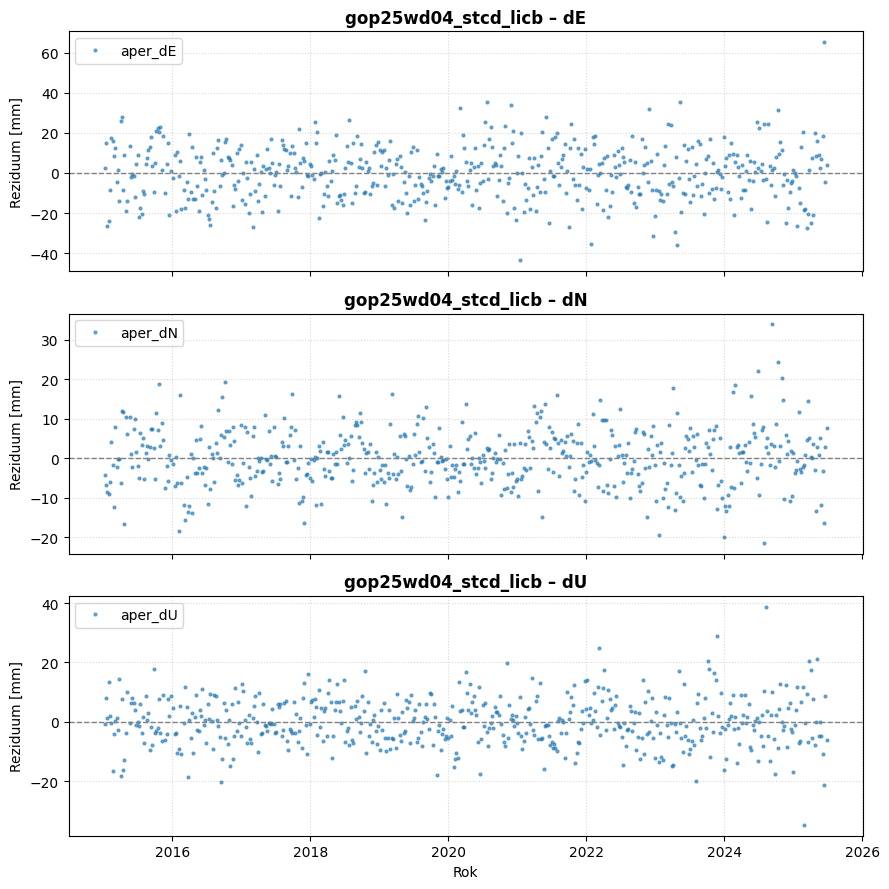

In [9]:
# --- Vizualizace aperiodickych rezidualu ---
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

for ax, comp in zip(axes, COMPONENTS):
    y = df_aper[f"aper_{comp}"]
    ax.plot(df_aper["year"], y, ".", ms=4, alpha=0.6, label=f"aper_{comp}")
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"{BASE_NAME} – {comp}", fontweight="bold")
    ax.set_ylabel("Reziduum [mm]")
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.legend(loc="best")

axes[-1].set_xlabel("Rok")
plt.tight_layout()
plt.show()


### Metoda 1: Klouzavé okno

In [10]:
# Parametry klouzaveho okna
window_size = 40   # W: velikost okna
shift       = 40   # s: posun mezi okny
sigma_mult  = 1    # nasobek sigma pro prah detekce

years  = df_aper["year"].values
sw_jumps  = {comp: [] for comp in COMPONENTS}
sw_mu1    = {}
sw_mu2    = {}
sw_years1 = {}
sw_years2 = {}

for comp in COMPONENTS:
    res = df_aper[f"aper_{comp}"].fillna(0).values
    sigma     = np.std(res)
    threshold = sigma_mult * sigma

    mu1_list, mu2_list, yrs1, yrs2 = [], [], [], []

    for n in range(len(res) - window_size - shift + 1):
        seg1 = res[n : n + window_size]
        seg2 = res[n + shift : n + shift + window_size]
        mu1, mu2 = seg1.mean(), seg2.mean()

        mu1_list.append(mu1)
        mu2_list.append(mu2)

        c1 = years[n : n + window_size].mean()
        c2 = years[n + shift : n + shift + window_size].mean()
        yrs1.append(c1)
        yrs2.append(c2)

        if abs(mu2 - mu1) > threshold:
            sw_jumps[comp].append(0.5 * (c1 + c2))

    sw_mu1[comp]    = np.array(mu1_list)
    sw_mu2[comp]    = np.array(mu2_list)
    sw_years1[comp] = np.array(yrs1)
    sw_years2[comp] = np.array(yrs2)

print("Detekce klouzavym oknem hotova.")
for comp in COMPONENTS:
    print(f"  {comp}: {len(sw_jumps[comp])} skok(u)")


Detekce klouzavym oknem hotova.
  dE: 0 skok(u)
  dN: 0 skok(u)
  dU: 0 skok(u)


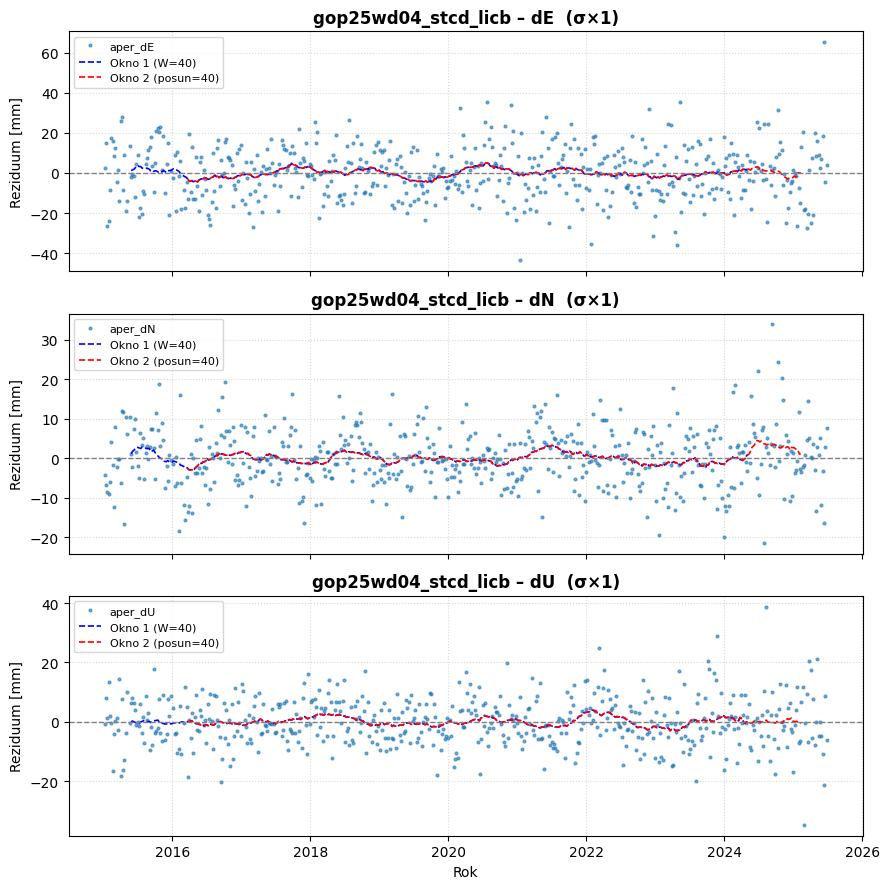

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

for ax, comp in zip(axes, COMPONENTS):
    y = df_aper[f"aper_{comp}"].to_numpy()
    x = df_aper["year"].to_numpy()

    ax.plot(x, y, ".", ms=4, alpha=0.6, label=f"aper_{comp}")
    ax.plot(sw_years1[comp], sw_mu1[comp], "b--", lw=1.2,
            label=f"Okno 1 (W={window_size})")
    ax.plot(sw_years2[comp], sw_mu2[comp], "r--", lw=1.2,
            label=f"Okno 2 (posun={shift})")

    first = True
    for xv in sw_jumps.get(comp, []):
        ax.axvline(xv, color="green", linestyle=":", alpha=0.8,
                   label="Detekovan\u00fd skok" if first else None)
        first = False

    ax.axhline(0, color="gray", ls="--", lw=1)
    ax.set_title(f"{BASE_NAME} – {comp}  (\u03c3\u00d7{sigma_mult})", fontweight="bold")
    ax.set_ylabel("Reziduum [mm]")
    ax.grid(True, ls=":", alpha=0.5)
    ax.legend(loc="best", fontsize=8)

axes[-1].set_xlabel("Rok")
plt.tight_layout()
fig.savefig(IMAGES_DIR / f"{IMAGE_NAME}_sliding_window.pdf", bbox_inches="tight", dpi=150)
plt.show()


### Metoda 2: Derivace LOWESS vyhlazování

In [12]:
# Parametry LOWESS detekce
frac_lowess   = 0.2   # zlomek dat pro vyhlazeni (mensi = mene hladke)
k_sigma_slope = 2     # nasobek sigma pro prah sklonu
min_slope_abs = 3.0   # minimalni absolutni prah sklonu [mm/rok]

def robust_scale(x):
    """Robust odhad smerodatne odchylky pomoci MAD."""
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    if mad == 0:
        s = np.std(x)
        return s if s > 0 else 1.0
    return 1.4826 * mad

def detect_derivative_jumps(years, res, frac=frac_lowess,
                             k=k_sigma_slope, min_abs=min_slope_abs):
    """Detekce skoku pomoci derivace LOWESS vyhlazeneho signalu."""
    smoothed    = lowess(res, years, frac=frac, return_sorted=False)
    slope       = np.diff(smoothed) / np.diff(years)
    t_mid       = (years[:-1] + years[1:]) / 2
    sigma_r     = robust_scale(slope)
    thr         = max(min_abs, k * sigma_r)
    deriv_jumps = t_mid[np.abs(slope) > thr]
    return {
        "smoothed":     smoothed,
        "t_mid":        t_mid,
        "slope":        slope,
        "thr":          thr,
        "deriv_jumps":  np.unique(np.round(deriv_jumps, 6)),
    }

print("Parametry: frac={}, k={}, min_abs={}".format(
    frac_lowess, k_sigma_slope, min_slope_abs))


Parametry: frac=0.2, k=2, min_abs=3.0


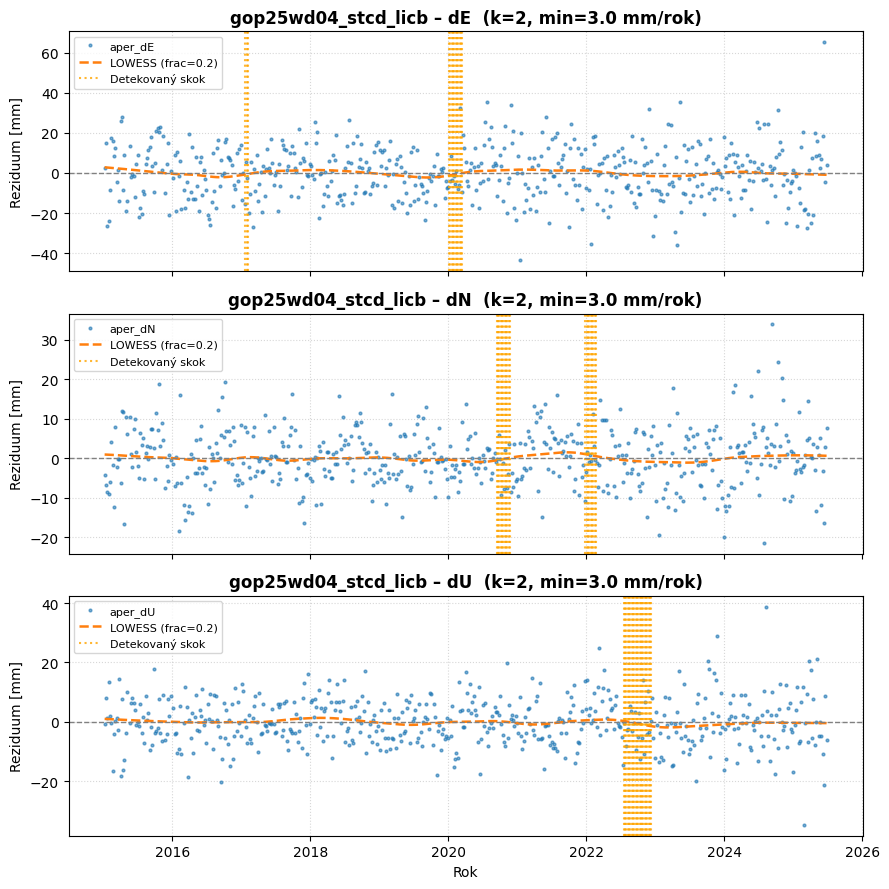

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

x = df_aper["year"].to_numpy()

for ax, comp in zip(axes, COMPONENTS):
    y   = df_aper[f"aper_{comp}"].fillna(0).to_numpy()
    det = detect_derivative_jumps(x, y)

    ax.plot(x, y, ".", ms=4, alpha=0.6, label=f"aper_{comp}")
    ax.plot(x, det["smoothed"], "--", lw=1.8,
            label=f"LOWESS (frac={frac_lowess})")

    first = True
    for xv in det["deriv_jumps"]:
        ax.axvline(xv, color="orange", ls=":", alpha=0.8,
                   label="Detekovan\u00fd skok" if first else None)
        first = False

    ax.axhline(0, color="gray", ls="--", lw=1)
    ax.set_title(
        f"{BASE_NAME} – {comp}  (k={k_sigma_slope}, min={min_slope_abs}\u00a0mm/rok)",
        fontweight="bold",
    )
    ax.set_ylabel("Reziduum [mm]")
    ax.grid(True, ls=":", alpha=0.5)
    h, l = ax.get_legend_handles_labels()
    ax.legend(dict(zip(l, h)).values(), dict(zip(l, h)).keys(),
              loc="best", fontsize=8)

axes[-1].set_xlabel("Rok")
plt.tight_layout()
fig.savefig(IMAGES_DIR / f"{IMAGE_NAME}_lowess_derivate.pdf", bbox_inches="tight", dpi=150)
plt.show()


### Metoda 3: Doris – po částech lineární trend (BIC)

Knihovna **doris** obsahuje funkci `fit_piecewise_trend`, která automaticky hledá bodové zlomy (breakpoints) v časové řadě pomocí BIC kritéria.  
Nalezené breakpointy odpovídají potenciálním skočům nebo změnám trendu.

In [14]:
# Detekce skoku pomoci doris.analysis.stations.fit_piecewise_trend
# Funkce hleda bodove zlomy (breakpointy) metodou BIC.
doris_jumps = {}

years_arr = df_aper["year"].values

for comp in COMPONENTS:
    y = df_aper[f"aper_{comp}"].fillna(0).values

    # fit_piecewise_trend: max_segments=None -> prida breakpointy dokud BIC klesa
    result = fit_piecewise_trend(years_arr, y, max_segments=None)

    doris_jumps[comp] = result.breakpoints
    n_seg = result.n_segments
    bic   = result.bic
    print(f"{comp}: {n_seg} segment(y), BIC={bic:.1f}, "
          f"breakpointy={[f'{bp:.3f}' for bp in result.breakpoints]}")


dE: 1 segment(y), BIC=2806.5, breakpointy=[]
dN: 1 segment(y), BIC=2152.4, breakpointy=[]
dU: 1 segment(y), BIC=2280.3, breakpointy=[]


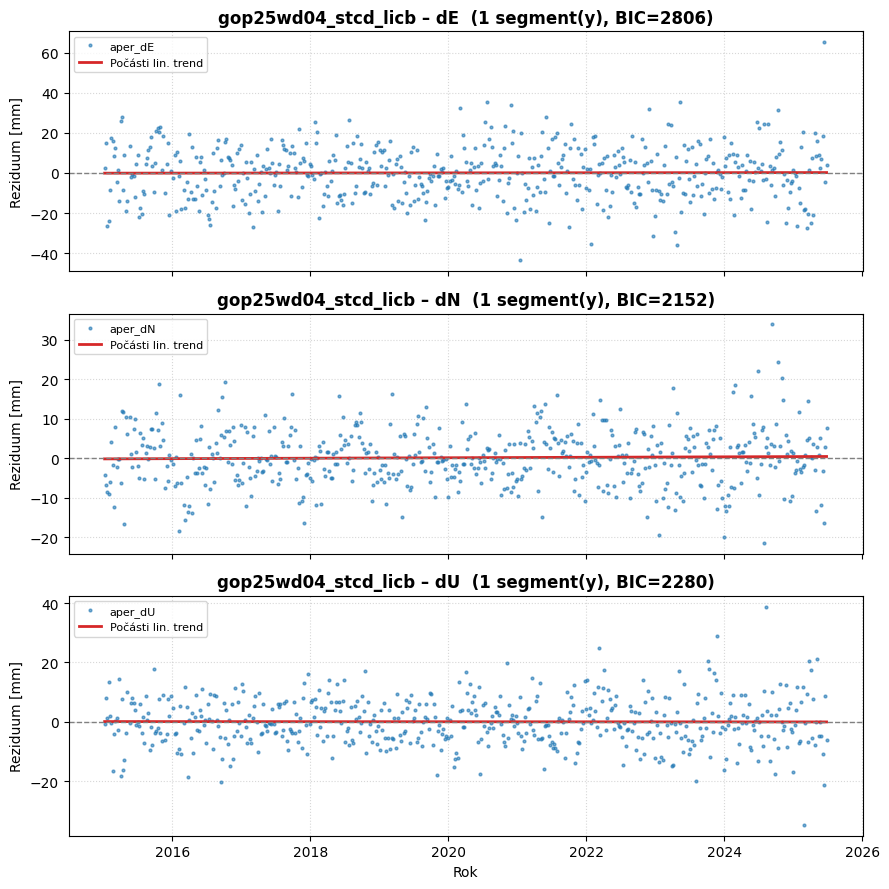

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

x = df_aper["year"].to_numpy()

for ax, comp in zip(axes, COMPONENTS):
    y      = df_aper[f"aper_{comp}"].fillna(0).to_numpy()
    result = fit_piecewise_trend(x, y, max_segments=None)

    # raw data
    ax.plot(x, y, ".", ms=4, alpha=0.6, label=f"aper_{comp}")

    # piecewise fitted line (segment by segment)
    breakpoints = result.breakpoints
    boundaries  = [-np.inf] + list(breakpoints) + [np.inf]
    for i in range(len(boundaries) - 1):
        mask = (x > boundaries[i]) & (x <= boundaries[i + 1])
        if mask.any():
            ax.plot(x[mask], result.fitted[mask], "-", lw=2,
                    color="tab:red", label="Počásti lin. trend" if i == 0 else None)

    # vertical lines at breakpoints
    first = True
    for bp in breakpoints:
        ax.axvline(bp, color="purple", ls="--", alpha=0.85,
                   label="Breakpoint (doris)" if first else None)
        first = False

    ax.axhline(0, color="gray", ls="--", lw=1)
    ax.set_title(
        f"{BASE_NAME} – {comp}  ({result.n_segments}\u00a0segment(y), "
        f"BIC={result.bic:.0f})",
        fontweight="bold",
    )
    ax.set_ylabel("Reziduum [mm]")
    ax.grid(True, ls=":", alpha=0.5)
    h, l = ax.get_legend_handles_labels()
    ax.legend(dict(zip(l, h)).values(), dict(zip(l, h)).keys(),
              loc="best", fontsize=8)

axes[-1].set_xlabel("Rok")
plt.tight_layout()
fig.savefig(IMAGES_DIR / f"{IMAGE_NAME}_doris_piecewise.pdf", bbox_inches="tight", dpi=150)
plt.show()
